In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
from src.models.baseline_cnn import BaselineCNN
from src.preprocessing.dataset_loader import build_dataset_index
from src.preprocessing.splitter import create_stratified_split
from src.preprocessing.dataloaders import create_datasets, create_dataloaders
from src.training.trainer import train_one_epoch, validate

import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

test_paths, test_labels = build_dataset_index(
    "../data/raw/test"
)

print(len(train_paths))
print(len(test_paths))

5216
624


In [4]:
X_train, X_val, y_train, y_val = create_stratified_split(
    train_paths,
    train_labels
)

In [5]:
train_dataset, val_dataset, test_dataset = create_datasets(
    X_train,
    y_train,
    X_val,
    y_val,
    test_paths,
    test_labels
)

In [6]:
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset
)

In [7]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [8]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

model = BaselineCNN().to(device)

cuda


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005
)

In [16]:
NUM_EPOCHS = 20
best_val_acc = 0.0

history = {

    "train_loss": [],
    "train_acc": [],

    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "../src/models/best_baseline_cnn.pth"
        )

        print(
            f"Best model saved "
            f"(Val Acc={val_acc:.4f})"
        )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Best model saved "
        f"(Val Acc={val_acc:.4f})"
    )

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Acc: {train_acc:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Acc: {val_acc:.4f}"
    )

Best model saved (Val Acc=0.9792)
Best model saved (Val Acc=0.9792)
Epoch 1/20
Train Loss: 0.1043
Train Acc: 0.9614
Val Loss: 0.0627
Val Acc: 0.9792
Best model saved (Val Acc=0.9697)
Epoch 2/20
Train Loss: 0.0938
Train Acc: 0.9630
Val Loss: 0.0773
Val Acc: 0.9697
Best model saved (Val Acc=0.9782)
Epoch 3/20
Train Loss: 0.0961
Train Acc: 0.9642
Val Loss: 0.0642
Val Acc: 0.9782
Best model saved (Val Acc=0.9820)
Best model saved (Val Acc=0.9820)
Epoch 4/20
Train Loss: 0.0998
Train Acc: 0.9599
Val Loss: 0.0540
Val Acc: 0.9820
Best model saved (Val Acc=0.9716)
Epoch 5/20
Train Loss: 0.1006
Train Acc: 0.9627
Val Loss: 0.0773
Val Acc: 0.9716
Best model saved (Val Acc=0.9763)
Epoch 6/20
Train Loss: 0.0975
Train Acc: 0.9625
Val Loss: 0.0656
Val Acc: 0.9763
Best model saved (Val Acc=0.9867)
Best model saved (Val Acc=0.9867)
Epoch 7/20
Train Loss: 0.0953
Train Acc: 0.9635
Val Loss: 0.0587
Val Acc: 0.9867
Best model saved (Val Acc=0.9621)
Epoch 8/20
Train Loss: 0.0920
Train Acc: 0.9648
Val Loss: 0

In [17]:
import json

with open(
    "../results/metrics/training_history.json",
    "w"
) as f:

    json.dump(
        history,
        f,
        indent=4
    )

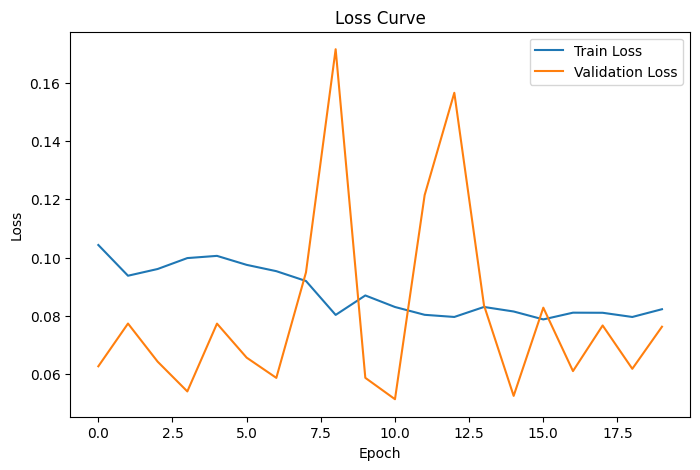

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title("Loss Curve")

plt.savefig(
    "../results/figures/loss_curve.png"
)

plt.show()

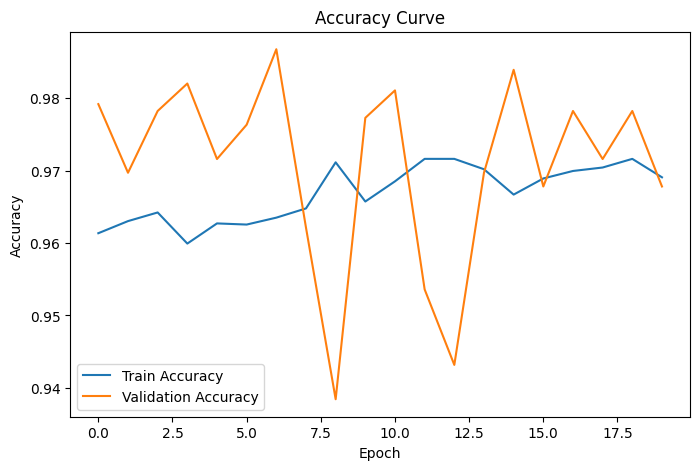

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Accuracy Curve")

plt.savefig(
    "../results/figures/accuracy_curve.png"
)

plt.show()